### **Project : Finacial Fraud Detection**
### **Algorithm : Random Forest Classifier**

In [28]:
# Step No 1 : Import Required Libraries 

# Import Numerical Library 
import numpy as np

# Import Pandas Library
import pandas as pd 

# Import Plotting Library 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import label encoder 
from sklearn.preprocessing import LabelEncoder

# Import Random Forest Classifier 
from sklearn.ensemble import RandomForestClassifier

# Import Evaluation metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [29]:
#  Step No 2 : Load Dataset 
df = pd.read_csv("Financial_Fraud_Dataset.csv")

In [30]:
# Step No 3 : Data Understanding 

# Display first rows 
print(df.head())

# Display shape 
print(df.shape)

# Display dataset information 
print(df.info())

# Display statistical summary 
print(df.describe())

   TransactionID  CustomerAge  ...  TransactionTime Fraud
0              1           56  ...               18     0
1              2           40  ...               20     0
2              3           19  ...               11     0
3              4           39  ...               15     0
4              5           32  ...                2     1

[5 rows x 9 columns]
(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      1000 non-null   int64  
 1   CustomerAge        1000 non-null   int64  
 2   TransactionAmount  1000 non-null   float64
 3   TransactionType    1000 non-null   object 
 4   AccountBalance     1000 non-null   float64
 5   LocationRisk       1000 non-null   int64  
 6   DeviceRisk         1000 non-null   int64  
 7   TransactionTime    1000 non-null   int64  
 8   Fraud              1000 non-nu

In [31]:
# Step No 4 : Data Cleaning 
# Check Missing Values 
print(df.isnull().sum())

# Check duplicate rows 
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

TransactionID        0
CustomerAge          0
TransactionAmount    0
TransactionType      0
AccountBalance       0
LocationRisk         0
DeviceRisk           0
TransactionTime      0
Fraud                0
dtype: int64
0


In [32]:
# Step No 5 : Encode Categorical Column 
# Create label encoder object 
encoder = LabelEncoder()

# Encode transactionType column 
df["TransactionType"] = encoder.fit_transform(df["TransactionType"])

In [33]:
# Step No 6 : Features and Target Splitting 

# Define input features 
X = df[[
    "CustomerAge",
    "TransactionAmount",
    "TransactionType",
    "AccountBalance",
    "LocationRisk",
    "DeviceRisk",
    "TransactionTime"
]]

# define target variable 
y = df["Fraud"]

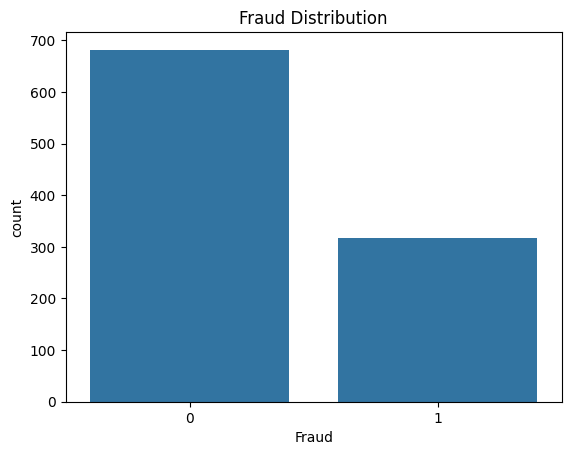

In [34]:
# Step No 7 : Visualization 
# Create count plot 
sns.countplot(x = "Fraud",data=df)

# Set title
plt.title("Fraud Distribution")

# Show Plot 
plt.show()

In [35]:
# Step No 8 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Step No 9 : Intialize Random Forest Model 
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
    
)

In [37]:
# Step No 10 : Train Model 
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [38]:
# Step No 11 : Prediction 
y_pred = model.predict(
    X_test
)
# Display Predicted Value 
print("Predicted Values : ")
print(y_pred)

Predicted Values : 
[0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 1 0 1 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 0
 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0]


In [39]:
# Step NO 12 : Model Evaluation 

# Accuracy Score 
print("Accuracy Score : ")
print(accuracy_score(y_test , y_pred ))

# Classification Report 
print("Classification Report : ")
print(classification_report(y_test , y_pred ))

# Confusion Matrix 
print("Confusion Matrix : ")
print(confusion_matrix(y_test , y_pred))

Accuracy Score : 
1.0
Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       131
           1       1.00      1.00      1.00        69

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix : 
[[131   0]
 [  0  69]]


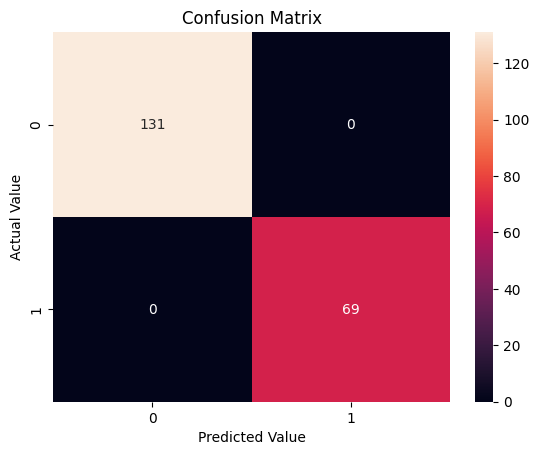

In [40]:
# Step No 13 : Confusion Matrix Visualization 
sns.heatmap(confusion_matrix(y_test , y_pred) , annot = True , fmt = "d")

# Set Title 
plt.title("Confusion Matrix")

# Set X-axis Label 
plt.xlabel("Predicted Value")

# Set Y-axis Label 
plt.ylabel("Actual Value")

# Display the output
plt.show() 

In [41]:
# Step No 14 : Feature Importance 
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort Values 
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance)

             Feature  Importance
6    TransactionTime    0.372483
1  TransactionAmount    0.238487
5         DeviceRisk    0.210334
4       LocationRisk    0.085987
3     AccountBalance    0.046211
0        CustomerAge    0.034322
2    TransactionType    0.012176


In [42]:
# Step No 15 : User Input 
customer_age = int(input("Enter Customer Age : "))

transaction_amount = float(input("Enter Transaction Amount : "))

transaction_type = input(
    "Enter Transaction Type (Online/POS/Transfer/ATM) : "
)

account_balance = float(input("Enter Account Balance : "))

location_risk = int(input("Enter Location Risk (0/1) : "))

device_risk = int(input("Enter Device risk (0/1)"))

transaction_time = int(input("Enter Transaction Time : "))



In [47]:
# Step No 16 : Encode User Transaction Type 
if transaction_type in encoder.classes_:
    transaction_type_encoded = encoder.transform([transaction_type])[0]
else:
    transaction_type_encoded = -1

In [51]:
user_data = pd.DataFrame({
    "CustomerAge": [customer_age],
    "TransactionAmount": [transaction_amount],
    "TransactionType": [transaction_type_encoded],  # ✅ FIXED
    "AccountBalance": [account_balance],
    "LocationRisk": [location_risk],
    "DeviceRisk": [device_risk],
    "TransactionTime": [transaction_time],
})

In [52]:
print(X.columns.tolist())
print(user_data.columns.tolist())

['CustomerAge', 'TransactionAmount', 'TransactionType', 'AccountBalance', 'LocationRisk', 'DeviceRisk', 'TransactionTime']
['CustomerAge', 'TransactionAmount', 'TransactionType', 'AccountBalance', 'LocationRisk', 'DeviceRisk', 'TransactionTime']


In [54]:
# Step No 18 : Final Prediction

# Ensure correct column order
user_data = user_data[X.columns]

result = model.predict(user_data)

print("Fraud Prediction Result:", result)

Fraud Prediction Result: [0]


In [55]:
# Step No 19 : Final Output 

if result[0] == 1:
    print("Fraudulent Transaction Detected")
    
else:
    print("Legitimate Transaction")

Legitimate Transaction
